In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# ── Load & clean ──────────────────────────────────────────────────────────────
df = pd.read_csv('data/allvisits.csv')

In [2]:
df['Diagnosed Influenza Count'] = pd.to_numeric(df['Diagnosed Influenza Count'], errors='coerce')
df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])
df = df[df['Health Region'] != 'Out of State']

REGIONS = sorted(df['Health Region'].unique())
REGION_COLORS = dict(zip(REGIONS, sns.color_palette('tab10', len(REGIONS))))

# ── PLOT 1: 2025 flu counts by region, weekly line chart ─────────────────────
df_2025 = df[df['Year'] == 2025]
df_2025_wk = (
    df_2025.groupby(['Week Ending Date', 'Health Region'], as_index=False)['Diagnosed Influenza Count'].sum()
)

df_2025_wk.head()

,Week Ending Date,Health Region,Diagnosed Influenza Count
0,2025-01-04,Central Region,3942.0
1,2025-01-04,Eastern Region,3449.0
2,2025-01-04,Northern Region,2788.0
3,2025-01-04,Northwest Region,1778.0
4,2025-01-04,Southwest Region,1236.0


Plot 1 saved


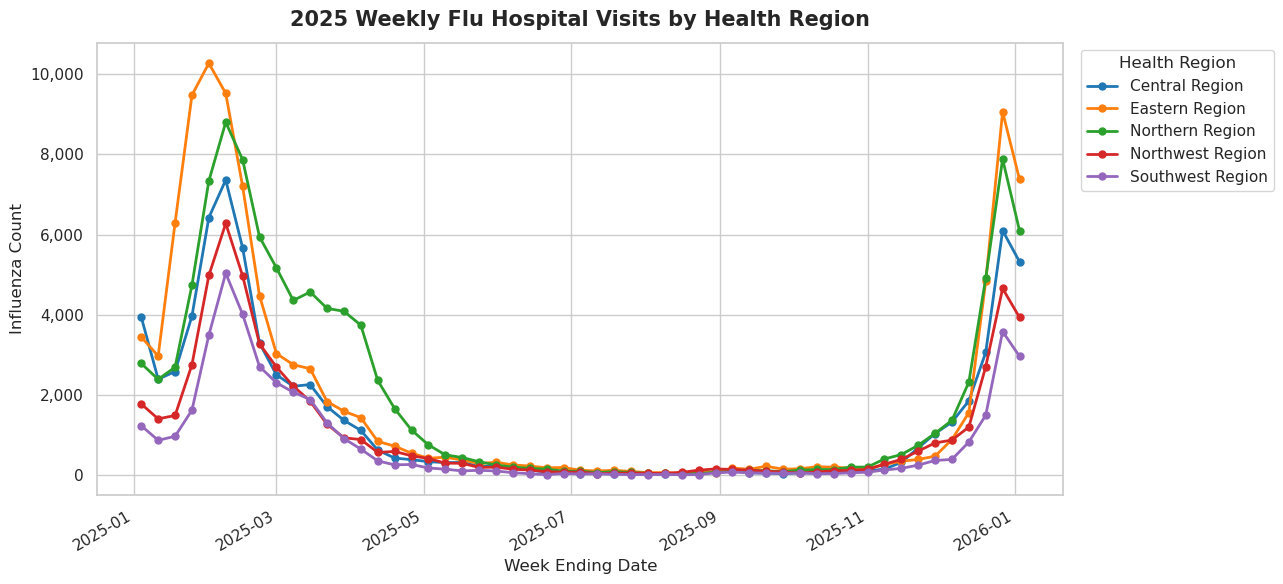

In [3]:


fig, ax = plt.subplots(figsize=(13, 6))
for region, grp in df_2025_wk.groupby('Health Region'):
    grp = grp.sort_values('Week Ending Date')
    ax.plot(grp['Week Ending Date'], grp['Diagnosed Influenza Count'],
            marker='o', markersize=5, label=region, color=REGION_COLORS[region], linewidth=2)

ax.set_title('2025 Weekly Flu Hospital Visits by Health Region', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Week Ending Date')
ax.set_ylabel('Influenza Count')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.legend(title='Health Region', bbox_to_anchor=(1.01, 1), loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
#plt.savefig('images/flu_2025_weekly_by_region.png', dpi=150, bbox_inches='tight')
#plt.close()
print("Plot 1 saved")

In [5]:


df['Diagnosed Influenza Count'] = pd.to_numeric(df['Diagnosed Influenza Count'], errors='coerce')
df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])
df = df[df['Health Region'] != 'Out of State']

REGIONS = sorted(df['Health Region'].unique())
REGION_COLORS = dict(zip(REGIONS, sns.color_palette('tab10', len(REGIONS))))

# ── PLOT 1: 2025 flu counts by region, weekly line chart ─────────────────────
df_2025 = df[df['Year'] == 2025]
df_2025_wk = (
    df_2025.groupby(['Week Ending Date', 'Health Region'], as_index=False)['Diagnosed Influenza Count'].sum()
)

fig, ax = plt.subplots(figsize=(13, 6))
for region, grp in df_2025_wk.groupby('Health Region'):
    grp = grp.sort_values('Week Ending Date')
    ax.plot(grp['Week Ending Date'], grp['Diagnosed Influenza Count'],
            marker='o', markersize=5, label=region, color=REGION_COLORS[region], linewidth=2)

ax.set_title('2025 Weekly Flu Hospital Visits by Health Region', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Week Ending Date')
ax.set_ylabel('Influenza Count')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.legend(title='Health Region', bbox_to_anchor=(1.01, 1), loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('images/flu_2025_weekly_by_region.png', dpi=150, bbox_inches='tight')
plt.close()
print("Plot 1 saved")

# ── PLOT 2: 2025 total flu by region (horizontal bar) ─────────────────────────
df_2025_totals = (
    df_2025.groupby('Health Region', as_index=False)['Diagnosed Influenza Count']
    .sum()
    .sort_values('Diagnosed Influenza Count')
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df_2025_totals['Health Region'], df_2025_totals['Diagnosed Influenza Count'],
               color=[REGION_COLORS[r] for r in df_2025_totals['Health Region']], edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in df_2025_totals['Diagnosed Influenza Count']], padding=5, fontsize=10)
ax.set_title('2025 Total Diagnosed Flu Visits by Health Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Influenza Count')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.set_xlim(0, df_2025_totals['Diagnosed Influenza Count'].max() * 1.18)
plt.tight_layout()
plt.savefig('images/flu_2025_totals_by_region.png', dpi=150, bbox_inches='tight')
plt.close()
print("Plot 2 saved")

# ── PLOT 3: All-years total flu by region (horizontal bar) ────────────────────
df_all_totals = (
    df.groupby('Health Region', as_index=False)['Diagnosed Influenza Count']
    .sum()
    .sort_values('Diagnosed Influenza Count')
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df_all_totals['Health Region'], df_all_totals['Diagnosed Influenza Count'],
               color=[REGION_COLORS[r] for r in df_all_totals['Health Region']], edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in df_all_totals['Diagnosed Influenza Count']], padding=5, fontsize=10)
ax.set_title('All-Years Total Diagnosed Flu Visits by Health Region\n(2020–2026, suppressed counts excluded)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Influenza Count')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.set_xlim(0, df_all_totals['Diagnosed Influenza Count'].max() * 1.18)
plt.tight_layout()
plt.savefig('images/flu_allyears_totals_by_region.png', dpi=150, bbox_inches='tight')
plt.close()
print("Plot 3 saved")

# ── PLOT 4: Annual flu totals by region — grouped bar ─────────────────────────
df_yr = (
    df.groupby(['Year', 'Health Region'], as_index=False)['Diagnosed Influenza Count'].sum()
)
pivot = df_yr.pivot(index='Year', columns='Health Region', values='Diagnosed Influenza Count').fillna(0)

x = np.arange(len(pivot))
n = len(pivot.columns)
width = 0.13
offsets = np.linspace(-(n-1)/2 * width, (n-1)/2 * width, n)

fig, ax = plt.subplots(figsize=(14, 6))
for i, col in enumerate(pivot.columns):
    bars = ax.bar(x + offsets[i], pivot[col], width=width, label=col,
                  color=REGION_COLORS[col], edgecolor='white')

ax.set_title('Annual Flu Hospital Visits by Health Region (All Years)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Influenza Count')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index.astype(int))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.legend(title='Health Region', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/flu_annual_by_region.png', dpi=150, bbox_inches='tight')
plt.close()
print("Plot 4 saved")

# ── PLOT 5: Heatmap — region × year ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
heat_data = pivot.T  # regions as rows, years as cols
sns.heatmap(heat_data, annot=True, fmt=',.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Influenza Count'}, ax=ax, annot_kws={'size': 9})
ax.set_title('Flu Visits Heatmap: Region × Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('images/flu_heatmap_region_year.png', dpi=150, bbox_inches='tight')
plt.close()
print("Plot 5 saved")

print("\nAll plots saved!")

Plot 1 saved
Plot 2 saved
Plot 3 saved
Plot 4 saved
Plot 5 saved

All plots saved!


In [6]:
what about a seaborn corr between data?trggggggggggg'/;;;;;;;;;poooooooooo


Object `data` not found.


In [7]:
I have three values A B and Sum.
I want to plot a line graph where A is x B is y and the Sum is the line

SyntaxError: invalid syntax (1588948396.py, line 1)